Solver Demos


In [1]:
import numpy as np
from anser import *
import os
os.chdir("/home/patrick/ansermodelling")
from models.eval import report_error_stats
from models import *
from models.train import pose_errors
import torch
import matplotlib.pyplot as plt


In [2]:
test_set = np.load("data/test_set.npz")
measurements = test_set["xs"]
poses = test_set["ys"]

In [3]:
coils_global = build_field_generator(N_turns,l,w,s,z_thick,centres,rotations)
f = lambda x : forward_model(x,coils_global)


In [4]:
lm = LMSolver(f,np.array([0.0,0.0,0.125,0.0,1.0,0.0])) 

In [5]:
%%time
poses_pred_lm, success_lm = lm.solve(measurements)

CPU times: user 16min 48s, sys: 109 ms, total: 16min 48s
Wall time: 16min 54s


In [6]:
report_error_stats(poses_pred_lm,poses,success_lm)

Mean pos error: 9.71, mean angle error: 8.95
Median pos error: 1.51e-11, Median angle error: 5.34e-12
95% pos error : 64.2 95% angle error: 79.5
LM success rate: 0.873
Convergence rate: 0.859
Mean pos error of converged: 0.00097, mean angle error of converged: 0.00105 


In [7]:
model = FFNN(input_dim=8, output_dim=6, hidden_dims=[256,256,256])
model.load_state_dict(torch.load("models/nn_normal.pt"))

<All keys matched successfully>

In [8]:
nn = NNSolver(model)

In [9]:
%%time
poses_pred_nn, success_nn = nn.solve(measurements)

CPU times: user 372 ms, sys: 32.4 ms, total: 405 ms
Wall time: 92.3 ms


In [10]:
report_error_stats(poses_pred_nn,poses,success_nn)

Mean pos error: 9.2, mean angle error: 6.43
Median pos error: 7.33, Median angle error: 3.62
95% pos error : 21.7 95% angle error: 20.7
LM success rate: 1
Convergence rate: 0.0008
Mean pos error of converged: 0.73, mean angle error of converged: 0.699 


In [11]:
hy = HybridSolver(model,f)

In [12]:
%%time
poses_pred_hy, success_hy = hy.solve(measurements)

CPU times: user 5min 44s, sys: 120 ms, total: 5min 44s
Wall time: 5min 46s


In [13]:
report_error_stats(poses_pred_hy,poses,success_hy)

Mean pos error: 1.12, mean angle error: 1.89
Median pos error: 3.83e-12, Median angle error: 1.21e-12
95% pos error : 1.67 95% angle error: 2.46
LM success rate: 0.958
Convergence rate: 0.947
Mean pos error of converged: 0.000849, mean angle error of converged: 0.00109 


In [14]:
ex_nn, en_nn = pose_errors(torch.as_tensor(poses_pred_nn,dtype = torch.float64),torch.as_tensor(poses,dtype=torch.float64))


In [15]:
ex_hy, en_hy = pose_errors(torch.as_tensor(poses_pred_hy,dtype = torch.float64),torch.as_tensor(poses,dtype=torch.float64))
ex_lm, en_lm = pose_errors(torch.as_tensor(poses_pred_lm,dtype = torch.float64),torch.as_tensor(poses,dtype=torch.float64))


/tmp/ipykernel_43092/4095371971.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.hist(np.maximum(e, floor), bins=bins, histtype="step",


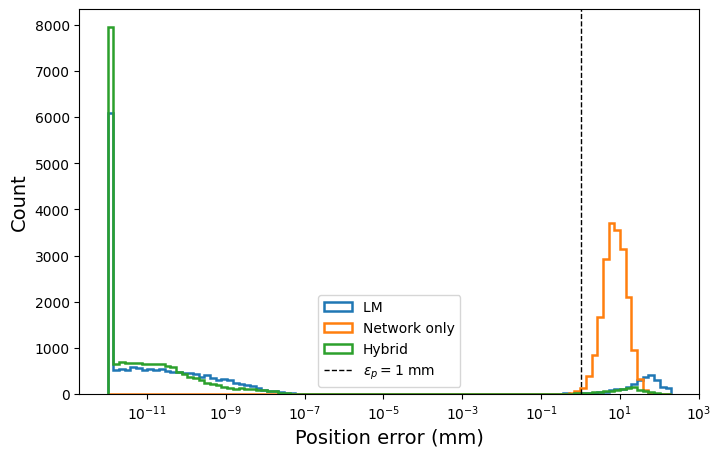

In [16]:
floor = 1e-12
bins = np.logspace(np.log10(floor), np.log10(200), 100)

fig, ax = plt.subplots(figsize=(8, 5))
for e, label in [(ex_lm, "LM "),
                 (ex_nn, "Network only"),
                 (ex_hy, "Hybrid")]:
    ax.hist(np.maximum(e, floor), bins=bins, histtype="step",
            lw=1.8, label=label)

ax.set_xscale("log")
ax.axvline(1.0, color="k", ls="--", lw=1, label=r"$\epsilon_p = 1$ mm")
ax.set_xlabel("Position error (mm)", fontsize = 14)
ax.set_ylabel("Count", fontsize = 14)
ax.legend()
plt.savefig("report/figs/three_way_pos.png")

/tmp/ipykernel_43092/2912464294.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax.hist(np.maximum(e, floor), bins=bins, histtype="step",


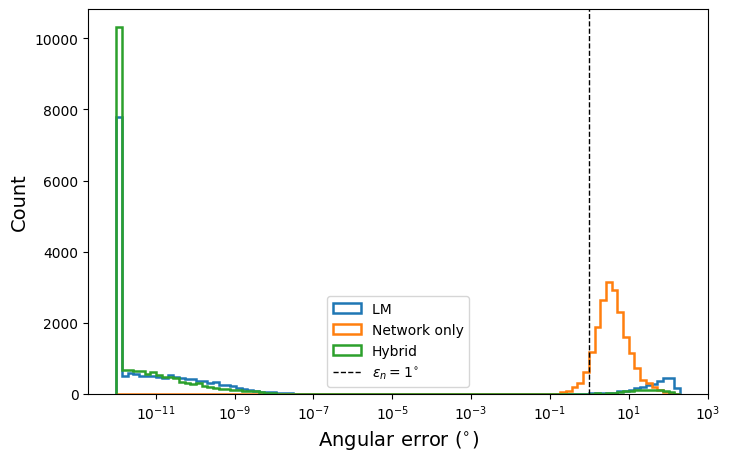

In [17]:
floor = 1e-12
bins = np.logspace(np.log10(floor), np.log10(200), 100)

fig, ax = plt.subplots(figsize=(8, 5))
for e, label in [(en_lm, "LM "),
                 (en_nn, "Network only"),
                 (en_hy, "Hybrid")]:
    ax.hist(np.maximum(e, floor), bins=bins, histtype="step",
            lw=1.8, label=label)

ax.set_xscale("log")
ax.axvline(1.0, color="k", ls="--", lw=1, label=r"$\epsilon_n = 1^{\circ}$")
ax.set_xlabel(r"Angular error ($^{\circ}$)", fontsize = 14)
ax.set_ylabel("Count", fontsize = 14)
ax.legend()
plt.savefig("report/figs/three_way_angle.png")

In [12]:
((ex_nn > 5) & (ex_nn < 15)).float().mean().item()

0.562749981880188